In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


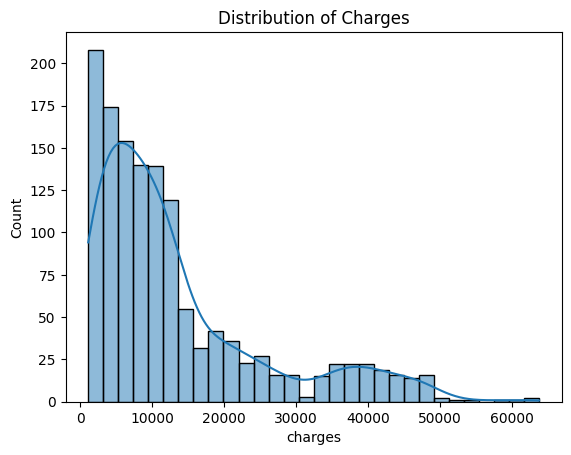

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

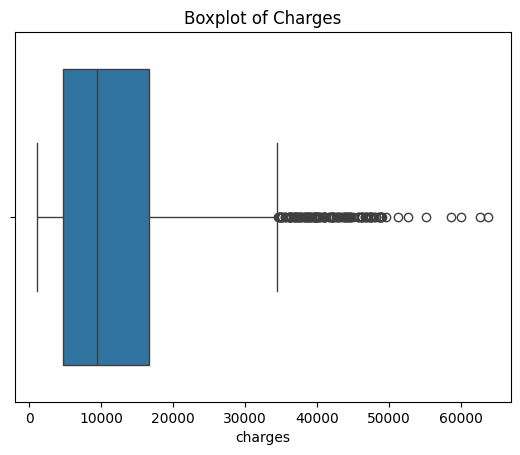

In [7]:
sns.boxplot(x=data['charges'])
plt.title("Boxplot of Charges")
plt.show()

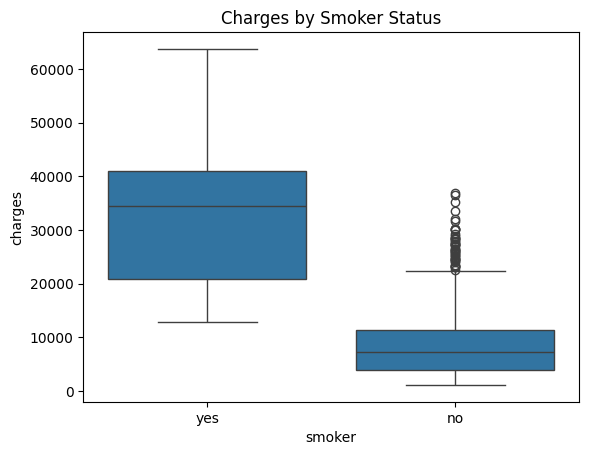

In [8]:
sns.boxplot(x='smoker', y='charges', data=data)
plt.title("Charges by Smoker Status")
plt.show()

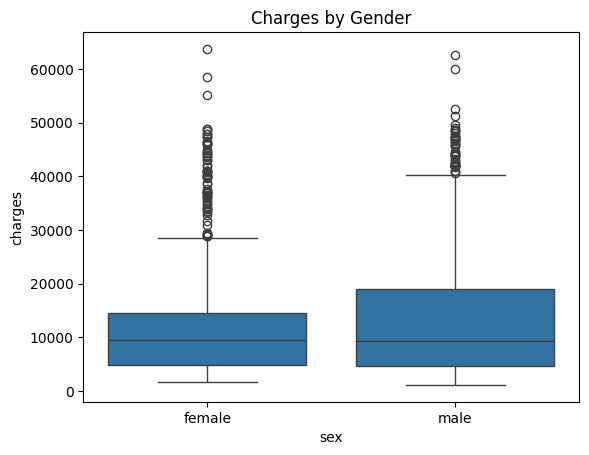

In [9]:
sns.boxplot(x='sex', y='charges', data=data)
plt.title("Charges by Gender")
plt.show()

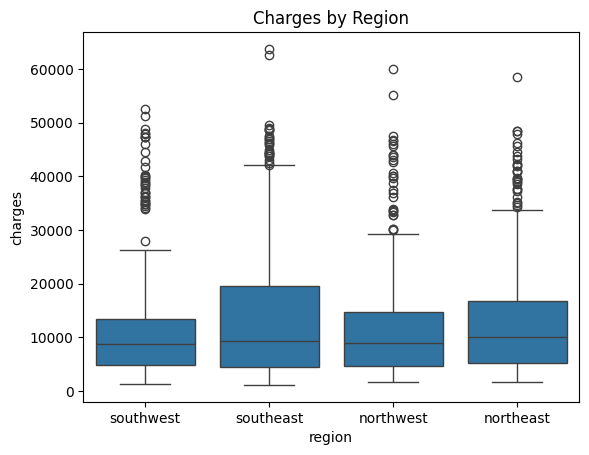

In [10]:
sns.boxplot(x='region', y='charges', data=data)
plt.title("Charges by Region")
plt.show()

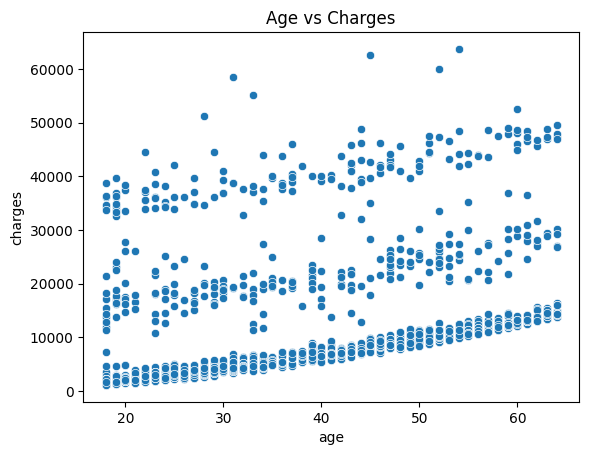

In [11]:
sns.scatterplot(x='age', y='charges', data=data)
plt.title("Age vs Charges")
plt.show()

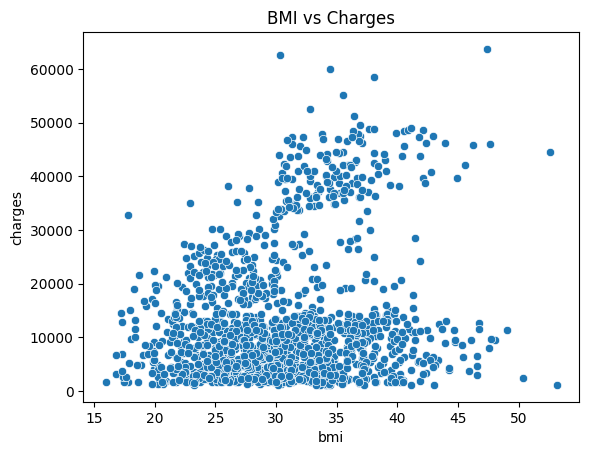

In [12]:
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title("BMI vs Charges")
plt.show()

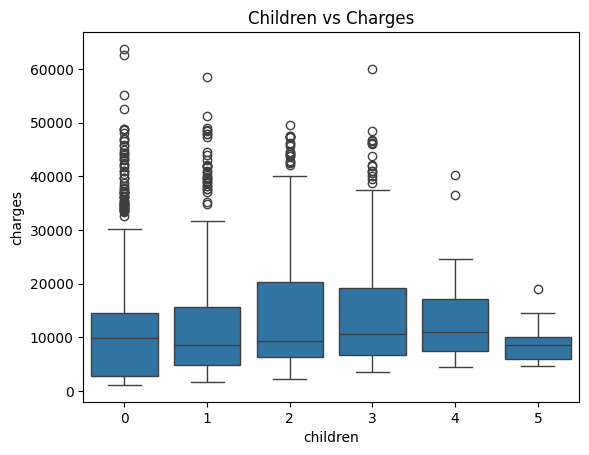

In [13]:
sns.boxplot(x='children', y='charges', data=data)
plt.title("Children vs Charges")
plt.show()

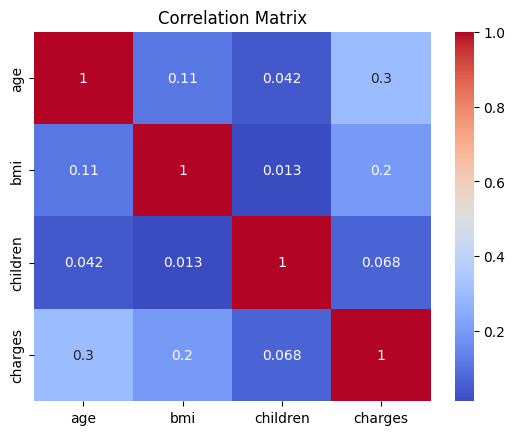

In [14]:
import seaborn as sns

corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
data.skew(numeric_only=True)

age             0.055673
bmi             0.284047
children        0.938380
charges         1.515880
is_obese       -0.113914
smoker_obese    2.522577
dtype: float64

In [15]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

data['bmi_category'] = data['bmi'].apply(bmi_category)

In [16]:
data['is_obese'] = (data['bmi'] >= 30).astype(int)

In [17]:
data['smoker_obese'] = data['is_obese'] * (data['smoker'] == 'yes').astype(int)

In [18]:
def age_group(age):
    if age < 30:
        return 'young'
    elif age < 50:
        return 'adult'
    else:
        return 'senior'

data['age_group'] = data['age'].apply(age_group)

In [20]:
import numpy as np

data['charges'] = np.log1p(data['charges'])

In [22]:
data.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,is_obese,smoker_obese,age_group
0,19,female,27.900,0,yes,southwest,9.734236,overweight,0,0,young
1,18,male,33.770,1,no,southeast,7.453882,obese,1,0,young
2,28,male,33.000,3,no,southeast,8.400763,obese,1,0,young
3,33,male,22.705,0,no,northwest,9.998137,normal,0,0,adult
4,32,male,28.880,0,no,northwest,8.260455,overweight,0,0,adult


In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1338 non-null   int64  
 1   sex           1338 non-null   str    
 2   bmi           1338 non-null   float64
 3   children      1338 non-null   int64  
 4   smoker        1338 non-null   str    
 5   region        1338 non-null   str    
 6   charges       1338 non-null   float64
 7   bmi_category  1338 non-null   str    
 8   is_obese      1338 non-null   int64  
 9   smoker_obese  1338 non-null   int64  
 10  age_group     1338 non-null   str    
dtypes: float64(2), int64(4), str(5)
memory usage: 115.1 KB


In [25]:
data = pd.get_dummies(data, drop_first=True)

In [26]:
data.head()

,age,bmi,children,charges,is_obese,smoker_obese,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_senior,age_group_young
0,19,27.900,0,9.734236,0,0,False,True,False,False,True,False,True,False,False,True
1,18,33.770,1,7.453882,1,0,True,False,False,True,False,True,False,False,False,True
2,28,33.000,3,8.400763,1,0,True,False,False,True,False,True,False,False,False,True
3,33,22.705,0,9.998137,0,0,True,False,True,False,False,False,False,False,False,False
4,32,28.880,0,8.260455,0,0,True,False,True,False,False,False,True,False,False,False


In [27]:
X = data.drop('charges', axis=1)
y = data['charges']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [30]:
pipelines = {

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel='rbf'))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(max_depth=5))
    ]),

    "XGBoost": Pipeline([
        ("model", XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        ))
    ])
}

In [31]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse
    }

In [32]:
results = []

for name, model in pipelines.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)

In [33]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model  R2 Score      RMSE
4            XGBoost  0.863093  0.350798
2                SVM  0.857342  0.358090
3      Decision Tree  0.846899  0.370965
0  Linear Regression  0.820567  0.401601
1                KNN  0.794790  0.429481
